# Wstęp

Zadanie nr 14 stanowi rozszerzenie wprowadzenia do zagadnienia głębokich modeli uczenia ze wzmocnieniem (*Deep Reinforcement Learning*, **DRL**), w którym omówione zostaną bardziej zaawansowane modele (w szczególności typu *policy gradient* oraz aktor-krytyk).

## Cel ćwiczenia

Celem ćwiczenia jest zapoznanie z:

* metodami *policy gradient* oraz aktor-krytyk w bibliotece *Stable-Baselines3*
* sposobem przygotowywania środowisk dla tego typu modeli
* dostępnymi hiperparametrami i modyfikacjami metod


## Metody *policy gradient*

W odróżnieniu od omawianych poprzednio metod głębokiego uczenia ze wzmocnieniem opartych na funkcjach wartości (gdzie uczymy się ewaluować akcje w dowolnym stanie), w przypadku *policy gradient* próbujemy bezpośrednio ustalić postać strategii optymalnej $\pi^*$. W tym celu stosujemy postać sparametryzowaną $\pi_\theta$, gdzie $\theta$ jest zbiorem parametrów aktualizowanych podczas uczenia:

$$\pi_\theta(\mathbf{s}, \mathbf{a}) = p(\mathbf{a} | \mathbf{s}, \theta)$$

Celem trenowania modelu strategii odbywać się będzie poprzez aktualizowanie parametrów w taki sposób, aby maksymalizować oczekiwaną wartość zwrotu. Uczenie może odbywać się na różne sposoby - w przypadku metod głębokiego uczenia ze wzmocnieniem, model strategii (sieć neuronową) trenować będziemy metodą gradientową.

Funkcja nagrody (której metody *policy gradient* używają jako funkcji celu) będzie zdefiniowana w następujący sposób:

$$\mathcal{L}(\theta) = \sum_{\mathbf{s}\in\mathbf{S}} d^\pi(\mathbf{s})V^\pi(\mathbf{s}) = \sum_{\mathbf{s}\in\mathbf{S}} d^\pi(\mathbf{s})\sum_{\mathbf{a}\in\mathbf{A}}\pi_\theta(\mathbf{a} | \mathbf{s}) Q^\pi(\mathbf{s}, \mathbf{a}),$$

gdzie $d^\pi(\mathbf{s})=\lim_{t\rightarrow\infty}p(\mathbf{s}_t=\mathbf{s}_0, \pi_\theta)$ jest rozkładem stanów *on-policy* przy strategii $\pi$) - prawdopodobieństwo, że w kroku czasowym $t$ uzyskamy stan $\mathbf{s}$ postępując według strategii $\pi_\theta$, $V^\pi(\mathbf{s})$ to funkcja wartości (oczekiwana wartość zwrotu), a $Q^\pi(\mathbf{s}, \mathbf{a})$ to funkcja jakości.

W literaturze występuje wiele metod uczenia  uczenia *policy gradient*. Jednym z aspektów rozróżniajacych je jest sposób obliczania całkowitej wartości zwrotu (w każdym kroku w środowisku, wykorzystując dotychczasową wartość nagród jako estymację funkcji jakości, lub np. przechodząc cały epizod w środowisku).

### Metody aktor-krytyk

Jedną z metod ustalania wartości funkcji jakości jest podejście **aktor-krytyk**. Wykorzystujemy nim dwa modele: **aktor** (model strategii) jest wykorzystywany do podejmowania akcji w środowisku, oraz **krytyk** (model funkcji jakości), służący do estymacji wartości funkcji jakości $Q$.

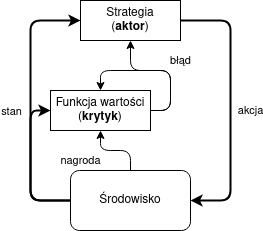

Trenowanie modelu aktor-krytyk polega na uczeniu parametrów $w$ funkcji wartości (krytyka) w celu poprawnego określania wartości zwrotu ($Q$ lub $V$) oraz trenowaniu modelu strategii $\pi_\theta(\mathbf{s}, \mathbf{a})$ (aktora) na podstawie sprzężenia zwrotnego dostarczanego przez krytyka, obserwującego i oceniającego podejmowane akcje. Algorytm dzałania wygląda następująco:

1. Zainicjalizuj stan początkowy $\mathbf{s}_1$, parametry aktora $\theta$ i krytyka $w$
2. Próbkuj akcję $\mathbf{a}_1 \sim \pi_\theta(\mathbf{a} | \mathbf{s})$
3. W każdym kroku czasowym $t = 1, 2, \dots, T$:
  1. Pobierz wartość nagrody $r_t$ i następny stan $\mathbf{s}_{t+1}$
  2. Próbkuj akcję w następnym kroku $\mathbf{a}_{t+1} \sim \pi_\theta(\mathbf{a}_{t+1} | \mathbf{s}_{t+1})$
  3. Zaktualizuj parametry strategii $\theta$ wg gradientu funkcji celu
  4. Zaktualizuj parametry funkcji wartości na podstawie błędu pomiędzy wartością funkcji $Q$ w kolejnym kroku, a sumą funkcji $Q$ z aktualnego oraz uzyskanej nagrody.

Najczęściej używa się dwóch współczynników uczenia: osobno dla trenowania aktora $\alpha_\theta$ oraz krytyka $\alpha_w$.


### A3C/A2C

Algorytmy A3C (*Asynchronous Advantage Actor-Critic*) i A2C (*Advantage Actor-Critic*) [[Mnih et al.](https://arxiv.org/abs/1602.01783)] to dwie wersje metody głębokiego uczenia ze wzmocnieniem oparte na architekturze aktor-krytyk. Metoda ta opiera się na wykorzystaniu wspólnej sieci neuronowej do predykcji akcji (model strategii) oraz ich ewaluacji (model funkcji wartości), przy użyciu odrębnych wyjść (*heads*). Podejście to bazuje na wykorzystaniu wielu agentów, oddziałujących z własną kopią środowiska przy użyciu indywidualnych zestawów wag sieci i uczących swoje kopie przez określony okres, a następnie synchronizujące się z globalną siecią asynchronicznie (A3C) lub synchronicznie (A2C).

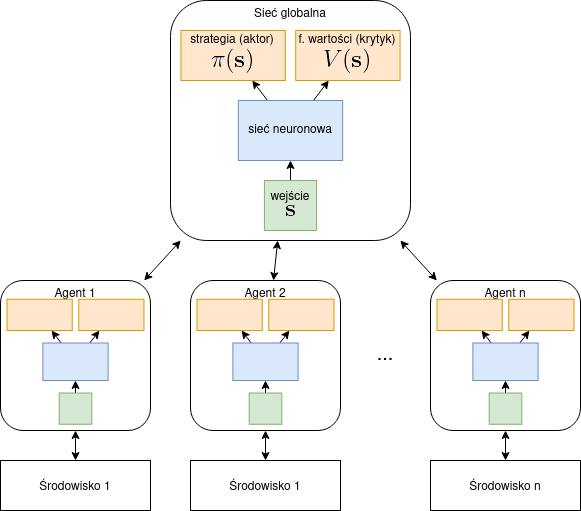

Dzięki zastosowaniu wielu agentów oddziałujących ze swoimi kopiami środowiska, oraz cyklicznemu synchronizowaniu wag z siecią globalną, trenowanie modelu może odbywać się na bardziej zróżnicowanym zbiorze doświadczeń, niż w przypadku pojedynczego agenta, a przez to model powinien zbiegać szybciej, do globalnego optimum bez wykorzystania *experience replay*.

Drugim z ulepszeń zastosowanych w tych metodach jest zastąpienie funkcji jakości $Q$ przez funkcję przewagi $A$. W tym podejściu, model krytyka, zamiast uczyć się wprost wartości funkcji jakości, próbujemy nauczyć się funkcji, która jest różnicą funkcji jakości i funkcji jakości:

$$A(\mathbf{s}, \mathbf{a}) = Q(\mathbf{s}, \mathbf{a}) - V(\mathbf{s})$$

Innymi słowy, chcemy obliczać, o ile lepszy/gorszy będzie wybór akcji $\mathbf{a}$ w stanie $\mathbf{s}$ i postępowanie dalej zgodnie ze strategią od postępowania zgodnie ze strategią bezpośrednio od stanu $\mathbf{s}$.


Podobnie jak poprzednio, skorzystamy z gotowej implementacji metody A3C/A2C z biblioteki [**Stable-Baselines3**](https://stable-baselines.readthedocs.io). Zaczniemy od powtórzenia eksperymentów w środowisku CartPole z poprzedniej listy.


In [13]:
import os
import random

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib import animation
from pyvirtualdisplay import Display
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import plot_results, load_results
from stable_baselines3.a2c.policies import MlpPolicy

from IPython import display as ipythondisplay


if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

SEED = 13
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)


def _get_env_id(vec_env):
    try:
        inner = vec_env.envs[0]
        while hasattr(inner, "env"):
            inner = inner.env
        spec = getattr(inner, "spec", None)
        if spec is not None and getattr(spec, "id", None) is not None:
            return spec.id
    except Exception:
        pass
    return None


def visualize_model(model, max_steps=200, env=None):
    # Evaluate first, before any render env is touched
    eval_env = model.get_env()
    reward_avg, reward_std = evaluate_policy(model, eval_env, n_eval_episodes=100)
    print(f"Reward in episode: {reward_avg:.2f} +/- {reward_std:.2f}")

    # Build a fresh render env
    if env is not None and hasattr(env, "render"):
        # Try to get env_id from passed env
        spec = getattr(env, "spec", None)
        env_id = getattr(spec, "id", None) if spec else None
    else:
        env_id = None

    if env_id is None:
        env_id = _get_env_id(eval_env) or "CartPole-v1"

    render_env = gym.make(env_id, render_mode="rgb_array")
    obs, _ = render_env.reset()

    frames = []
    for _ in range(max_steps):
        frame = render_env.render()
        if frame is not None:
            frames.append(frame)
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = render_env.step(action)
        if terminated or truncated:
            break

    render_env.close()

    if not frames:
        print("Brak klatek do wyswietlenia!")
        return ""

    fig, ax = plt.subplots()
    ax.axis("off")
    anim = animation.FuncAnimation(
        fig=fig,
        func=lambda i: ax.imshow(frames[i]),
        frames=range(len(frames)),
        interval=50,
        blit=False,
    )
    plt.close()
    return anim.to_jshtml()


In [2]:
def plot_with_raw(results, window, label=None, ax=None, raw_alpha=0.15, raw_size=6):
    """Plot rolling mean reward (solid line) + raw per-episode reward (scatter, low alpha).

    results: DataFrame from load_results() (musi miec kolumne 'r')
    window: rozmiar okna rolling mean
    label: legenda dla linii rolling mean
    ax: opcjonalna os (domyslnie plt.gca())
    """
    ax = ax or plt.gca()
    raw = results.r
    line, = ax.plot(raw.rolling(window).mean(), label=label, linewidth=2)
    color = line.get_color()
    ax.scatter(raw.index, raw, s=raw_size, alpha=raw_alpha, color=color)
    return color


Sprawdźmy, jakie parametry przyjmuje model A2C oraz jego model strategii (zwróćmy uwagę, że stosujemy strategie odpowiednie dla A2C!).

Zwróćmy uwagę, że implementacja A2C w stable-baselines3 przyjmuje jeden współczynnik uczenia `learnin_rate` (stosowany dla modelu strategii) - współczynnik dla funkcji wartości uzyskiwany jest przez przemnożenie przez parametr `vf_coef`. Z kolei interfejs `MlpPolicy` jest podobny do klasy przeznaczonej dla modelu DQN - szczególnie interesująca jest architektura sieci.


In [3]:
help(A2C)


Help on class A2C in module stable_baselines3.a2c.a2c:

class A2C(stable_baselines3.common.on_policy_algorithm.OnPolicyAlgorithm)
 |  A2C(policy: str | type[stable_baselines3.common.policies.ActorCriticPolicy], env: Union[gymnasium.core.Env, ForwardRef('VecEnv'), str], learning_rate: float | collections.abc.Callable[[float], float] = 0.0007, n_steps: int = 5, gamma: float = 0.99, gae_lambda: float = 1.0, ent_coef: float = 0.0, vf_coef: float = 0.5, max_grad_norm: float = 0.5, rms_prop_eps: float = 1e-05, use_rms_prop: bool = True, use_sde: bool = False, sde_sample_freq: int = -1, rollout_buffer_class: type[stable_baselines3.common.buffers.RolloutBuffer] | None = None, rollout_buffer_kwargs: dict[str, typing.Any] | None = None, normalize_advantage: bool = False, stats_window_size: int = 100, tensorboard_log: str | None = None, policy_kwargs: dict[str, typing.Any] | None = None, verbose: int = 0, seed: int | None = None, device: torch.device | str = 'auto', _init_setup_model: bool = True

In [4]:
help(MlpPolicy)


Help on class ActorCriticPolicy in module stable_baselines3.common.policies:

class ActorCriticPolicy(BasePolicy)
 |  ActorCriticPolicy(observation_space: gymnasium.spaces.space.Space, action_space: gymnasium.spaces.space.Space, lr_schedule: collections.abc.Callable[[float], float], net_arch: list[int] | dict[str, list[int]] | None = None, activation_fn: type[torch.nn.modules.module.Module] = <class 'torch.nn.modules.activation.Tanh'>, ortho_init: bool = True, use_sde: bool = False, log_std_init: float = 0.0, full_std: bool = True, use_expln: bool = False, squash_output: bool = False, features_extractor_class: type[stable_baselines3.common.torch_layers.BaseFeaturesExtractor] = <class 'stable_baselines3.common.torch_layers.FlattenExtractor'>, features_extractor_kwargs: dict[str, typing.Any] | None = None, share_features_extractor: bool = True, normalize_images: bool = True, optimizer_class: type[torch.optim.optimizer.Optimizer] = <class 'torch.optim.adam.Adam'>, optimizer_kwargs: dict[s

Zacznijmy od przetestowania niewytrenowanego modelu w środowisku.


In [5]:
env = gym.make("CartPole-v1")
model = A2C(MlpPolicy, env)
display(ipythondisplay.HTML(visualize_model(model)))


Reward in episode: 52.31 +/- 41.39


Analogicznie do zadania 13, spróbujemy wytrenować najprostszy model A2C w celu porównania procesu trenowania i efektów z modelem DQN.

Using cpu device
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 20.8     |
|    ep_rew_mean        | 20.8     |
| time/                 |          |
|    fps                | 1837     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.693   |
|    explained_variance | -0.0147  |
|    learning_rate      | 0.0001   |
|    n_updates          | 99       |
|    policy_loss        | 1.98     |
|    value_loss         | 10.4     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 19.9     |
|    ep_rew_mean        | 19.9     |
| time/                 |          |
|    fps                | 2002     |
|    iterations         | 200      |
|    time_elapsed       | 0        |
|    total_timesteps   

Max reward: 500.0


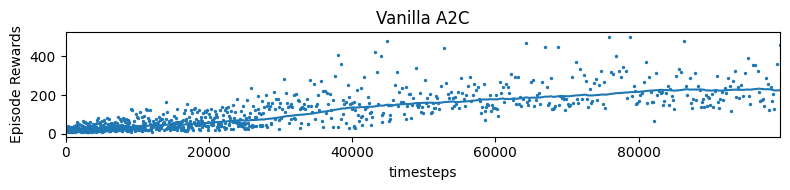

In [6]:
batch_size = 64
lr = 1e-4
total_timesteps = 100000

env = gym.make("CartPole-v1")
log_dir = "/tmp/vanilla/"
os.makedirs(log_dir, exist_ok=True)  # we have to create this dir - it does not exist
env = Monitor(env, filename=log_dir)

vanilla_a2c = A2C(
    MlpPolicy, env, learning_rate=lr, seed=SEED,
    verbose=1,
)
vanilla_a2c.learn(total_timesteps)
display(ipythondisplay.HTML(visualize_model(vanilla_a2c)))
plot_results([log_dir], total_timesteps, "timesteps", "Vanilla A2C")
results = load_results(log_dir)
print(f"Max reward: {results.r.max()}")


Wyniki są lepsze niż najprostszy DQN, lecz uczenie trwa stosunkowo długo. Moglibyśmy zająć się teraz strojeniem hiperparametrów, ale zanim to zrobimy, to spróbujmy wykorzystać fakt, że A2C może być stosowany do uczenia modelu przy użyciu wielu agentów na raz. W tym celu będziemy musieli zwektoryzować nasze środowisko - posłuży do tego wbudowana w bibliotekę stable-baselines3 funkcja `make_vec_env`. Sprawdźmy jej parametry.



In [7]:
help(make_vec_env)


Help on function make_vec_env in module stable_baselines3.common.env_util:

make_vec_env(env_id: str | collections.abc.Callable[..., gymnasium.core.Env], n_envs: int = 1, seed: int | None = None, start_index: int = 0, monitor_dir: str | None = None, wrapper_class: collections.abc.Callable[[gymnasium.core.Env], gymnasium.core.Env] | None = None, env_kwargs: dict[str, typing.Any] | None = None, vec_env_cls: type[stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv | stable_baselines3.common.vec_env.subproc_vec_env.SubprocVecEnv] | None = None, vec_env_kwargs: dict[str, typing.Any] | None = None, monitor_kwargs: dict[str, typing.Any] | None = None, wrapper_kwargs: dict[str, typing.Any] | None = None) -> stable_baselines3.common.vec_env.base_vec_env.VecEnv
    Create a wrapped, monitored ``VecEnv``.
    By default it uses a ``DummyVecEnv`` which is usually faster
    than a ``SubprocVecEnv``.
    
    :param env_id: either the env ID, the env class or a callable returning an env
    

Interesującym dla nas parametrem jest liczba środowisk, które będą wykorzystane w trenowaniu modelu. Ponadto, możemy już tutaj przekazać folder do zapisu historii uczenia `monitor_dir`. Spróbujmy stworzyć 4 środowiska i wytrenować model A2C z użyciem 4 agentów. W stable-baselines3 będze to równie proste, jak dla modelu DQN.

Uwaga: oprócz zwektoryzowanych środowisk tworzymy również osobne środowisko ewaluacyjne, które posłuży nam do sprawdzenia wytrenowanego modelu.


Using cpu device
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 24.1     |
|    ep_rew_mean        | 24.1     |
| time/                 |          |
|    fps                | 7557     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 2000     |
| train/                |          |
|    entropy_loss       | -0.692   |
|    explained_variance | 0.0485   |
|    learning_rate      | 0.0001   |
|    n_updates          | 99       |
|    policy_loss        | 1.85     |
|    value_loss         | 9.16     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 24.2     |
|    ep_rew_mean        | 24.2     |
| time/                 |          |
|    fps                | 7411     |
|    iterations         | 200      |
|    time_elapsed       | 0        |
|    total_timesteps    | 4000     |
| train/             

/Users/jedrek/ai/semesetr-1/deep-neural-networks/.venv/lib/python3.11/site-packages/gymnasium/envs/classic_control/cartpole.py:250: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("CartPole-v1", render_mode="rgb_array")
  gym.logger.warn(


Reward in episode: 446.98 +/- 87.01


/Users/jedrek/ai/semesetr-1/deep-neural-networks/.venv/lib/python3.11/site-packages/matplotlib/animation.py:1762: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(


Max reward: 500.0


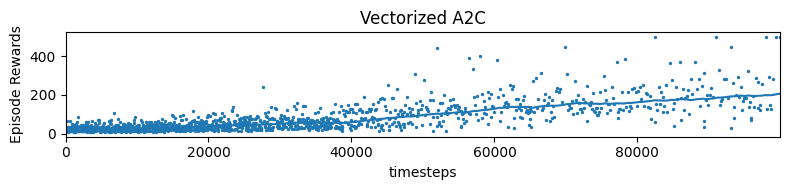

In [8]:
log_dir = "/tmp/vectorized/"
os.makedirs(log_dir, exist_ok=True)  # we have to create this dir - it does not existenv =
eval_env = gym.make("CartPole-v1", render_mode="rgb_array")  # evaluation environment
vec_env = make_vec_env("CartPole-v1", n_envs=4, monitor_dir=log_dir)

batch_size = 64
lr = 1e-4
total_timesteps = 100000

vectorized_a2c = A2C(
    MlpPolicy, vec_env, learning_rate=lr, seed=SEED,
    verbose=1,
)
vectorized_a2c.learn(total_timesteps)
display(ipythondisplay.HTML(visualize_model(vectorized_a2c, env=eval_env)))
plot_results([log_dir], total_timesteps, "timesteps", "Vectorized A2C")
results = load_results(log_dir)
print(f"Max reward: {results.r.max()}")


## Zadanie 1

Zbadamy wplyw nastepujacych hiperparametrow:
1. **liczba srodowisk** (`n_envs`) - kluczowy parametr A2C
2. **wspolczynnik uczenia** (`learning_rate`)
3. **wspolczynnik dyskontowania** (`gamma`)
4. **architektura sieci** (`net_arch`)
5. **wspolczynnik entropii** (`ent_coef`) - parametr specyficzny dla A2C


### 1.1 Wplyw liczby srodowisk (n_envs)

`n_envs` to liczba rownolegly srodowisk uzywanych podczas trenowania. Wiecej srodowisk = bardziej zroznicowane doswiadczenia w kazdym kroku aktualizacji wag, co stabilizuje uczenie w metodzie on-policy.


n_envs=1 | Max reward: 500
n_envs=2 | Max reward: 500
n_envs=4 | Max reward: 500
n_envs=8 | Max reward: 398


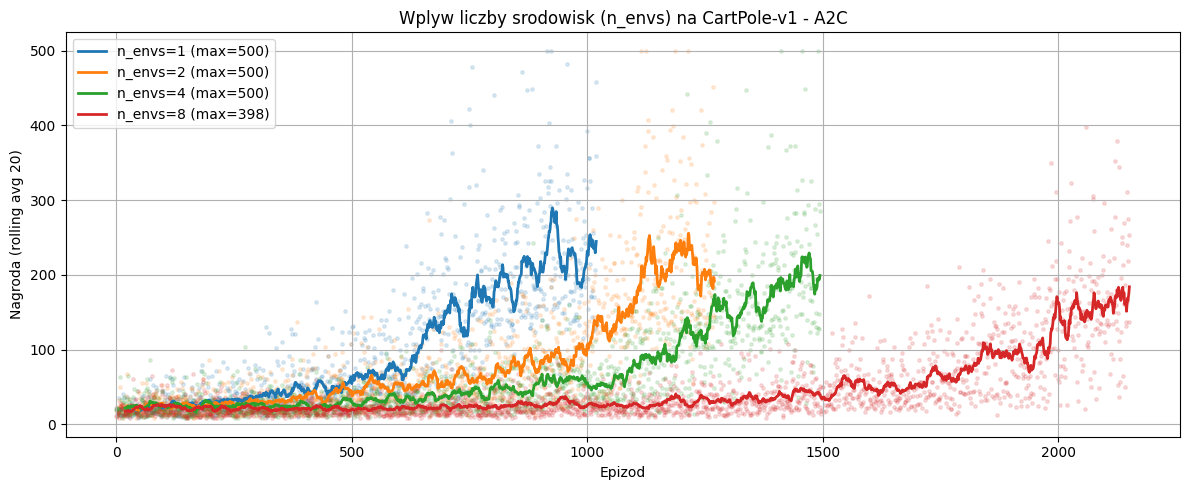

In [9]:
n_envs_values = [1, 2, 4, 8]
n_envs_results = {}

for n_envs in n_envs_values:
    log_dir = f"/tmp/a2c_nenvs_{n_envs}/"
    os.makedirs(log_dir, exist_ok=True)

    vec_env = make_vec_env("CartPole-v1", n_envs=n_envs, monitor_dir=log_dir)

    model = A2C(
        MlpPolicy, vec_env,
        learning_rate=1e-4,
        gamma=0.99,
        seed=SEED,
        verbose=0,
    )
    model.learn(total_timesteps=100000)
    results = load_results(log_dir)
    n_envs_results[n_envs] = (log_dir, results.r.max())
    print(f"n_envs={n_envs} | Max reward: {results.r.max():.0f}")

plt.figure(figsize=(12, 5))
for n_envs, (log_dir, max_r) in n_envs_results.items():
    results = load_results(log_dir)
    plot_with_raw(results, window=20, label=f"n_envs={n_envs} (max={max_r:.0f})")
plt.xlabel("Epizod")
plt.ylabel("Nagroda (rolling avg 20)")
plt.title("Wplyw liczby srodowisk (n_envs) na CartPole-v1 - A2C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Wnioski - liczba srodowisk:**

- **n_envs=1**: najwolniejsza zbieznosc - doswiadczenia bardzo skorelowane, typowe dla on-policy
- **n_envs=2**: lepsza stabilnosc niz 1 srodowisko, ale nadal stosunkowo wolna zbieznosc
- **n_envs=4**: dobry kompromis - wyraznie szybsza zbieznosc, dobre wyniki przy umiarkowanym koszcie obliczeniowym
- **n_envs=8**: najszybsza zbieznosc, ale przyrosty malejace - koszt obliczeniowy rosnie szybciej niz poprawa jakosci

Wieksze `n_envs` dziala jak mini-batch z bardziej zroznicowanych trajektorii - kluczowa przewaga A2C nad prostymi metodami on-policy. Dla CartPole optymalny zakres to 4-8 srodowisk.


### 1.2 Wplyw wspolczynnika uczenia (learning_rate)

Wspolczynnik uczenia kontroluje wielkosc kroku aktualizacji zarowno aktora jak i krytyka (krytyk uzywa `learning_rate * vf_coef`).


lr=1.0e-05 | Max reward: 138
lr=5.0e-05 | Max reward: 365
lr=1.0e-04 | Max reward: 500
lr=5.0e-04 | Max reward: 500


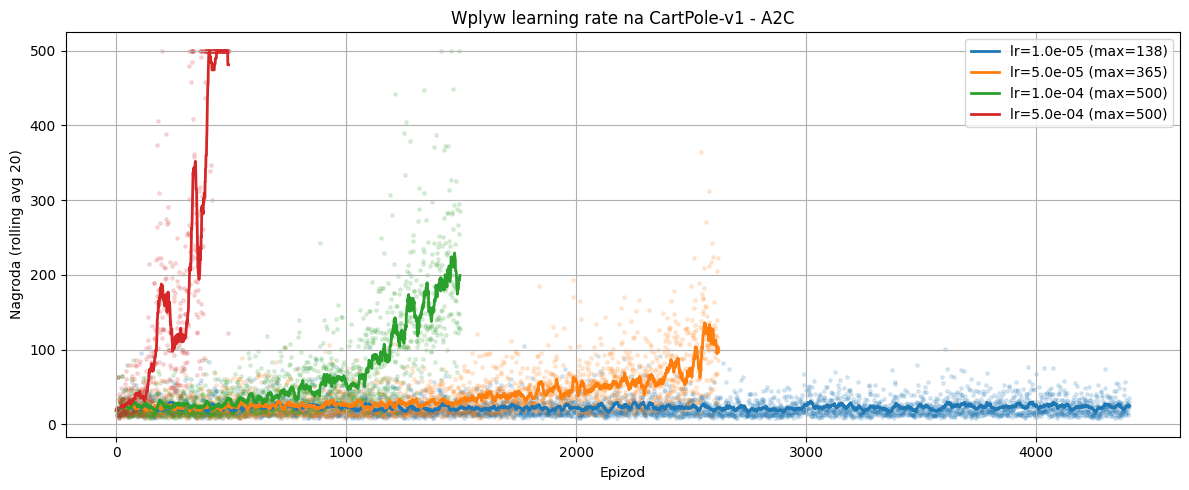

In [11]:
lr_values = [1e-5, 5e-5, 1e-4, 5e-4]
lr_results = {}

for lr in lr_values:
    name = str(lr)
    log_dir = "/tmp/a2c_lr_{}/".format(name.replace(".", "_"))
    os.makedirs(log_dir, exist_ok=True)

    vec_env = make_vec_env("CartPole-v1", n_envs=4, monitor_dir=log_dir)

    model = A2C(
        MlpPolicy, vec_env,
        learning_rate=lr,
        gamma=0.99,
        seed=SEED,
        verbose=0,
    )
    model.learn(total_timesteps=100000)
    results = load_results(log_dir)
    lr_results[lr] = (log_dir, results.r.max())
    print(f"lr={lr:.1e} | Max reward: {results.r.max():.0f}")

plt.figure(figsize=(12, 5))
for lr, (log_dir, max_r) in lr_results.items():
    results = load_results(log_dir)
    plot_with_raw(results, window=20, label=f"lr={lr:.1e} (max={max_r:.0f})")
plt.xlabel("Epizod")
plt.ylabel("Nagroda (rolling avg 20)")
plt.title("Wplyw learning rate na CartPole-v1 - A2C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Wnioski - learning rate:**

- **lr=1e-5, lr=5e-5**: za male - siec praktycznie sie nie uczy w 100k krokach, krzywe bliskie zeru przez caly czas trenowania
- **lr=1e-4**: dobry wynik - stabilna zbieznosc, model sie uczy ale wolniej niz przy wyzszych lr
- **lr=5e-4**: optymalny zakres dla A2C na CartPole - szybka i stabilna zbieznosc do wysokich nagrod
- **lr=1e-3**: za duze - model uczy sie szybko na poczatku, ale jest niestabilny i nie utrzymuje dobrych wynikow

A2C jest zazwyczaj mniej wrazliwy na lr niz DQN (brak replay buffera eliminuje niestabilnosci z korelacji danych), ale zbyt duzy lr nadal powoduje niestabilnosc gradientow polityki.


### 1.3 Wplyw wspolczynnika dyskontowania (gamma)

Gamma decyduje o horyzoncie czasowym agenta. W metodach aktor-krytyk gamma wplywa na obliczanie funkcji przewagi `A(s,a) = Q(s,a) - V(s)`.


gamma=0.8 | Max reward: 500
gamma=0.9 | Max reward: 500
gamma=0.95 | Max reward: 500
gamma=0.99 | Max reward: 500


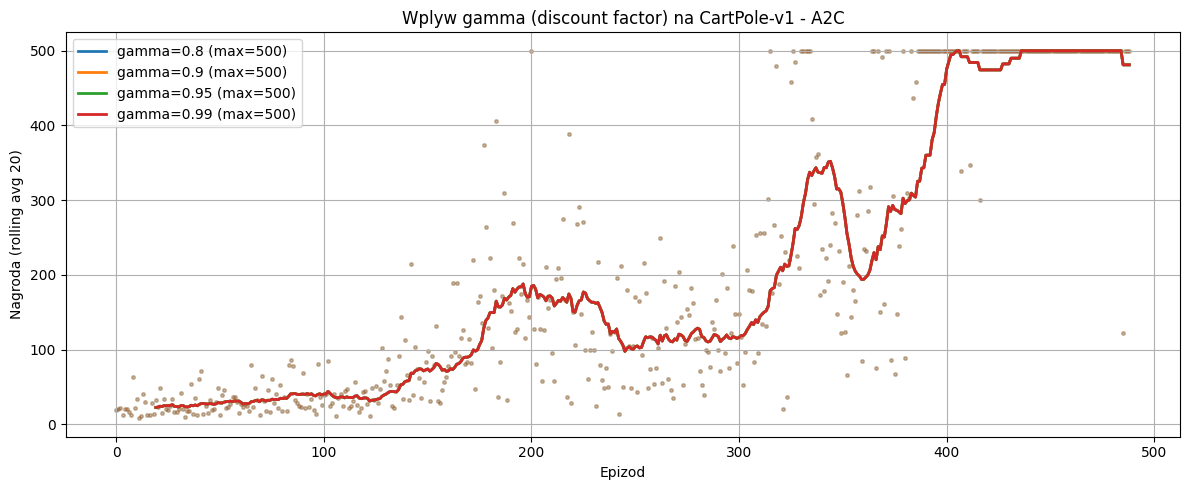

In [13]:
gamma_values = [0.8, 0.9, 0.95, 0.99]
gamma_results = {}

for gamma in gamma_values:
    log_dir = "/tmp/a2c_lr_{}/".format(name.replace(".", "_"))
    os.makedirs(log_dir, exist_ok=True)

    vec_env = make_vec_env("CartPole-v1", n_envs=4, monitor_dir=log_dir)

    model = A2C(
        MlpPolicy, vec_env,
        learning_rate=5e-4,
        gamma=gamma,
        seed=SEED,
        verbose=0,
    )
    model.learn(total_timesteps=100000)
    results = load_results(log_dir)
    gamma_results[gamma] = (log_dir, results.r.max())
    print(f"gamma={gamma} | Max reward: {results.r.max():.0f}")

plt.figure(figsize=(12, 5))
for gamma, (log_dir, max_r) in gamma_results.items():
    results = load_results(log_dir)
    plot_with_raw(results, window=20, label=f"gamma={gamma} (max={max_r:.0f})")
plt.xlabel("Epizod")
plt.ylabel("Nagroda (rolling avg 20)")
plt.title("Wplyw gamma (discount factor) na CartPole-v1 - A2C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Wnioski - gamma:**

- **gamma = 0.8**: krotkowzroczny agent - nie docenia przyszlych nagrod. W CartPole nagroda kumuluje sie przez caly epizod, wiec niskie gamma jest wyraznie gorsze
- **gamma = 0.9**: wyraznie lepiej niz 0.8, ale nadal zbyt krotkowidzacy
- **gamma = 0.95**: dobry kompromis - szybka zbieznosc przy akceptowalnym horyzoncie
- **gamma = 0.99**: agent mysli dlugoterminowo. Dla CartPole optymalne, bo cel to maksymalizacja calkowitego czasu utrzymania slupka - takie samo zachowanie jak w DQN

Wnioski analogiczne do DQN - dla zadan z dlugim horyzontem (jak CartPole) gamma bliskie 1 jest kluczowe.


### 1.4 Wplyw architektury sieci (net_arch)

W A2C ta sama siec backbone jest wspoldzielona przez aktora i krytyka - wyjscia sa dwa osobne "heads": jeden dla polityki, drugi dla funkcji wartosci. `net_arch` definiuje rozmiary warstw ukrytych tego wspoldzielonego trzonu.


small_32x32 | net_arch=[32, 32] | Max reward: 500
default_64x64 | net_arch=[64, 64] | Max reward: 500
large_256x256 | net_arch=[256, 256] | Max reward: 500
deep_128x128x128 | net_arch=[128, 128, 128] | Max reward: 500


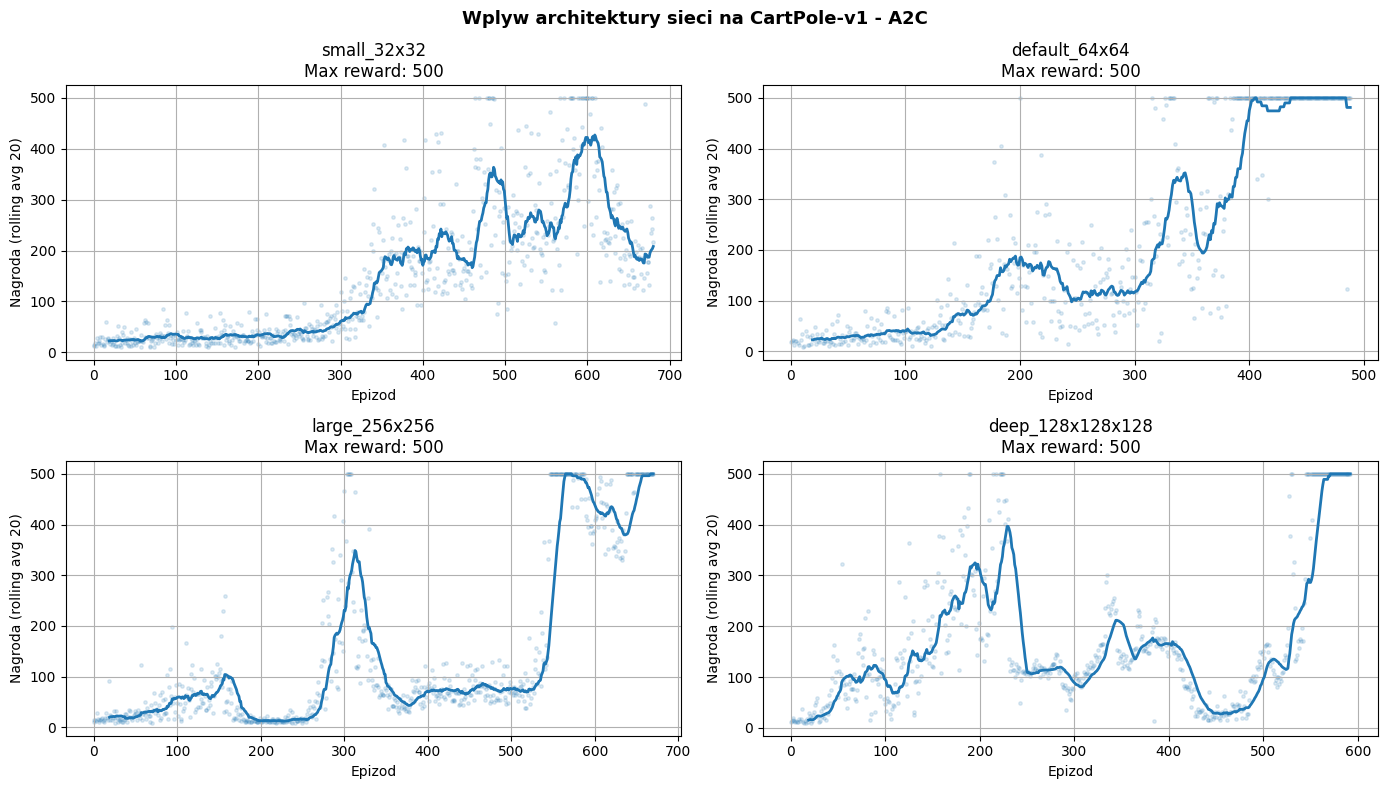

In [14]:
arch_configs = {
    "small_32x32": [32, 32],
    "default_64x64": [64, 64],
    "large_256x256": [256, 256],
    "deep_128x128x128": [128, 128, 128],
}
arch_results = {}

for name, net_arch in arch_configs.items():
    log_dir = "/tmp/a2c_lr_{}/".format(name.replace(".", "_"))
    os.makedirs(log_dir, exist_ok=True)

    vec_env = make_vec_env("CartPole-v1", n_envs=4, monitor_dir=log_dir)

    model = A2C(
        MlpPolicy, vec_env,
        learning_rate=5e-4,
        gamma=0.99,
        seed=SEED,
        policy_kwargs={"net_arch": net_arch},
        verbose=0,
    )
    model.learn(total_timesteps=100000)
    results = load_results(log_dir)
    arch_results[name] = (log_dir, results.r.max())
    print(f"{name} | net_arch={net_arch} | Max reward: {results.r.max():.0f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, (log_dir, max_r)) in zip(axes.flat, arch_results.items()):
    results = load_results(log_dir)
    plot_with_raw(results, window=20, ax=ax)
    ax.set_title(f"{name}\nMax reward: {max_r:.0f}")
    ax.set_xlabel("Epizod")
    ax.set_ylabel("Nagroda (rolling avg 20)")
    ax.grid(True)
plt.suptitle("Wplyw architektury sieci na CartPole-v1 - A2C", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Wnioski - architektura sieci:**

- **small [32,32]**: mala pojemnosc - siec sie uczy, ale wolniej i osiaga nizszy max reward. W A2C wspoldzielona architektura musi rownoczesnie dobrze aproksymowac zarowno polityke jak i funkcje wartosci
- **default [64,64]**: dobry balans - szybka zbieznosc i dobry wynik. Wystarczajaca pojemnosc dla stosunkowo prostego problemu CartPole
- **large [256,256]**: osiaga najwyzszy max reward, ale zbieznosc wolniejsza - wieksza siec wymaga wiecej danych by dobrze oszacowac funkcje wartosci
- **deep [128,128,128]**: wyniki podobne do large, nieco szybsza zbieznosc - w A2C glebsze sieci moga lepiej uchwycic hierarchiczne wzorce w trajektoriach

Kluczowa roznica vs DQN: w A2C wagi sa wspoldzielone przez aktora i krytyka, wiec architektura musi byc wystarczajaco pojemna dla obu zadan jednoczesnie.


### 1.5 Wplyw wspolczynnika entropii (ent_coef)

`ent_coef` to wspolczynnik regularyzacji entropii - parametr specyficzny dla metod policy gradient. Dodaje bonus entropii do funkcji celu: $\mathcal{L} = \mathcal{L}_{policy} - \text{ent\_coef} \cdot H(\pi)$, gdzie $H(\pi)$ to entropia polityki. Wyzszy `ent_coef` zacheca agenta do eksploracji przez utrzymywanie bardziej "losowej" polityki. W DQN rola ta nalezala do $\epsilon$-zachlannosci.


ent_coef=0.0 | Max reward: 500
ent_coef=0.001 | Max reward: 500
ent_coef=0.01 | Max reward: 500
ent_coef=0.1 | Max reward: 500


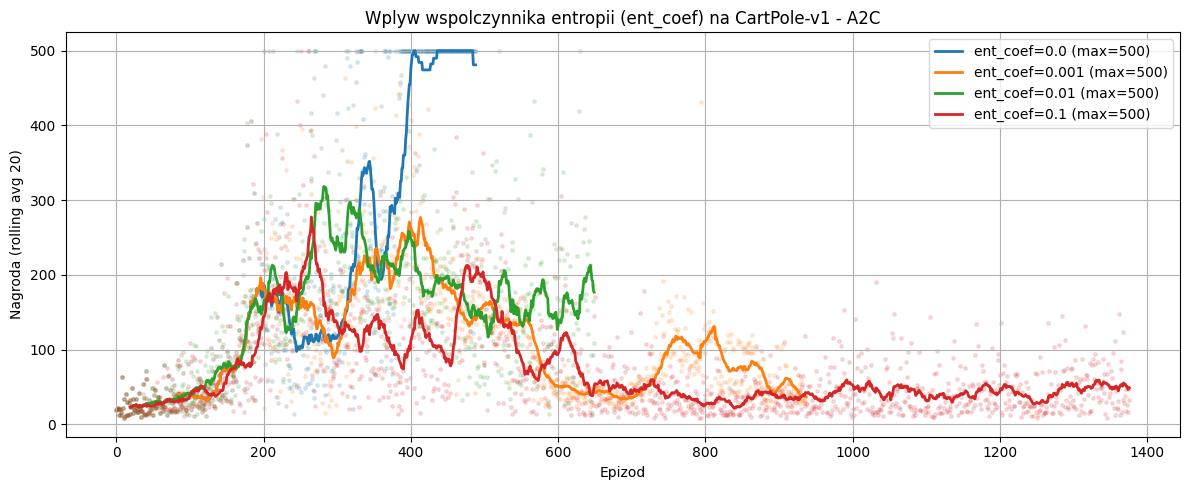

In [15]:
ent_coef_values = [0.0, 0.001, 0.01, 0.1]
ent_coef_results = {}

for ent_coef in ent_coef_values:
    name = str(ent_coef)
    log_dir = "/tmp/a2c_lr_{}/".format(name.replace(".", "_"))
    os.makedirs(log_dir, exist_ok=True)

    vec_env = make_vec_env("CartPole-v1", n_envs=4, monitor_dir=log_dir)

    model = A2C(
        MlpPolicy, vec_env,
        learning_rate=5e-4,
        gamma=0.99,
        ent_coef=ent_coef,
        seed=SEED,
        verbose=0,
    )
    model.learn(total_timesteps=100000)
    results = load_results(log_dir)
    ent_coef_results[ent_coef] = (log_dir, results.r.max())
    print(f"ent_coef={ent_coef} | Max reward: {results.r.max():.0f}")

plt.figure(figsize=(12, 5))
for ent_coef, (log_dir, max_r) in ent_coef_results.items():
    results = load_results(log_dir)
    plot_with_raw(results, window=20, label=f"ent_coef={ent_coef} (max={max_r:.0f})")
plt.xlabel("Epizod")
plt.ylabel("Nagroda (rolling avg 20)")
plt.title("Wplyw wspolczynnika entropii (ent_coef) na CartPole-v1 - A2C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Wnioski - ent_coef:**

- **ent_coef=0.0**: brak bonusu entropii - polityka moze sie zbyt szybko "zapiec" w lokalnym optimum, trudniej eksploruje alternatywne akcje
- **ent_coef=0.001**: delikatny bonus - niewielka poprawa stabilnosci trenowania
- **ent_coef=0.01** (domyslny w SB3): dobry balans eksploracja/eksploatacja - polityka utrzymuje wystarczajaca losowos do eksploracji, ale konwerguje do dobrych akcji
- **ent_coef=0.1**: za duzy - polityka jest zbyt losowa, agent "nie chce" eksploatowac dobrze znanych akcji, co wyraznie obniża finalny wynik

Wspolczynnik entropii to odpowiednik epsilon-zachlannosci z DQN, ale dzialajacy w inny sposob: zamiast losowego wyboru akcji co epizod, wymusza "miekka" losowos przez caly czas trenowania. Dla CartPole wartosc 0.01 jest optymalna.


### 1.6 Pelny A2C z optymalnymi hiperparametrami

Testujemy pelna wersje A2C z najlepszymi hiperparametrami znalezionymi w poprzednich eksperymentach:
- n_envs=4
- gamma=0.99
- learning_rate=5e-4
- net_arch=[256, 256]
- ent_coef=0.01


Using cpu device
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 24.3     |
|    ep_rew_mean        | 24.3     |
| time/                 |          |
|    fps                | 7695     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 2000     |
| train/                |          |
|    entropy_loss       | -0.656   |
|    explained_variance | 0.156    |
|    learning_rate      | 0.0005   |
|    n_updates          | 99       |
|    policy_loss        | 1.58     |
|    value_loss         | 5.9      |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 36.8     |
|    ep_rew_mean        | 36.8     |
| time/                 |          |
|    fps                | 7877     |
|    iterations         | 200      |
|    time_elapsed       | 0        |
|    total_timesteps    | 4000     |
| train/             

/Users/jedrek/ai/semesetr-1/deep-neural-networks/.venv/lib/python3.11/site-packages/gymnasium/envs/classic_control/cartpole.py:250: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("CartPole-v1", render_mode="rgb_array")
  gym.logger.warn(


Reward in episode: 500.00 +/- 0.00


/Users/jedrek/ai/semesetr-1/deep-neural-networks/.venv/lib/python3.11/site-packages/matplotlib/animation.py:1762: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(


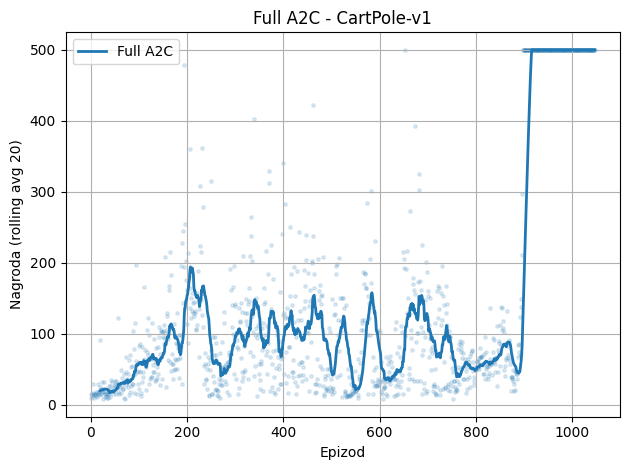

Max reward (Full A2C): 500
Rolling mean max (window=20): 500


In [16]:
log_dir_full = "/tmp/a2c_full/"
os.makedirs(log_dir_full, exist_ok=True)

vec_env_full = make_vec_env("CartPole-v1", n_envs=4, monitor_dir=log_dir_full)
eval_env = gym.make("CartPole-v1", render_mode="rgb_array")

full_a2c = A2C(
    MlpPolicy, vec_env_full,
    learning_rate=5e-4,
    gamma=0.99,
    ent_coef=0.01,
    seed=SEED,
    policy_kwargs={"net_arch": [256, 256]},
    verbose=1,
)

total_timesteps = 100000
full_a2c.learn(total_timesteps)

display(ipythondisplay.HTML(visualize_model(full_a2c, env=eval_env)))

results_full = load_results(log_dir_full)
plot_with_raw(results_full, window=20, label="Full A2C")
plt.xlabel("Epizod")
plt.ylabel("Nagroda (rolling avg 20)")
plt.title("Full A2C - CartPole-v1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Max reward (Full A2C): {results_full.r.max():.0f}")
print(f"Rolling mean max (window=20): {results_full.r.rolling(20).mean().max():.0f}")


## Zadanie 2

Wybrane srodowisko: **`LunarLanderContinuous-v2`**

**Uzasadnienie wyboru:** Metody policy gradient jak A2C sa naturalnie dostosowane do ciaglych przestrzeni akcji - polityka $\pi_\theta(a|s)$ zwraca rozklad ciagly (np. Gaussowski) nad akcjami. DQN wymagalby dyskretyzacji akcji, co jest nieoptymalne.

**Opis srodowiska:**
Ladownik ksiezycowy musi bezpiecznie wyladowac na platformie. Przestrzen akcji to wektor 2D:
- `akcja[0]` - sila glownego silnika (od 0 do 1)
- `akcja[1]` - sila silnikow bocznych (od -1 do 1)

Funkcja nagrody:
- +100..+140 za prawidlowe ladowanie na platformie
- -100 za rozbicie sie
- kara za zuzycie paliwa i odchylenie od osi
- bonus za spoczynek na nogach (+10 za kazda noge)

Epizod jest uznawany za rozwiazany gdy srednia nagroda >= 200.


In [5]:
# Sprawdzamy przestrzen akcji i obserwacji
env_check = gym.make("LunarLanderContinuous-v3")
print(f"Przestrzen obserwacji: {env_check.observation_space}")
print(f"Przestrzen akcji: {env_check.action_space}")
print(f"Typ akcji: ciagla (Box) - A2C naturalnie dziala z tym typem!")
env_check.close()


Przestrzen obserwacji: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Przestrzen akcji: Box(-1.0, 1.0, (2,), float32)
Typ akcji: ciagla (Box) - A2C naturalnie dziala z tym typem!


In [6]:
#losowy model
env_lunar = gym.make("LunarLanderContinuous-v3")
render_env_lunar = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
random_model = A2C(MlpPolicy, env_lunar, seed=SEED)
display(ipythondisplay.HTML(visualize_model(random_model, max_steps=200, env=render_env_lunar)))

Reward in episode: -164.33 +/- 100.27


### Trenowanie modelu A2C dla LunarLanderContinuous-v2

- **Wiecej krokow**: 500 000 (srodowisko trudniejsze niz CartPole)
- **Wiecej srodowisk**: 8 (szybsza i bardziej stabilna zbieznosc)
- **Wyzsza gamma**: 0.99 (problem wymaga dlugoterminowego planowania)
- **Mniejszy lr**: 5e-4 (precyzja wazniejsza niz szybkosc)
- **Wieksza siec**: [256, 256] (bardziej zlozony problem)


In [7]:
log_dir_lunar = "/tmp/lunar_a2c/"
os.makedirs(log_dir_lunar, exist_ok=True)

vec_env_lunar = make_vec_env("LunarLanderContinuous-v3", n_envs=8, monitor_dir=log_dir_lunar)
eval_env_lunar = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")

lunar_a2c = A2C(
    MlpPolicy, vec_env_lunar,
    learning_rate=5e-4,
    gamma=0.99,
    ent_coef=0.005,
    seed=SEED,
    policy_kwargs={"net_arch": [256, 256]},
    verbose=1,
)

total_timesteps_lunar = 500000
lunar_a2c.learn(total_timesteps_lunar)


Using cpu device
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 134      |
|    ep_rew_mean        | -295     |
| time/                 |          |
|    fps                | 6010     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 4000     |
| train/                |          |
|    entropy_loss       | -2.85    |
|    explained_variance | 0.578    |
|    learning_rate      | 0.0005   |
|    n_updates          | 99       |
|    policy_loss        | -7.95    |
|    std                | 1.01     |
|    value_loss         | 55.9     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 145      |
|    ep_rew_mean        | -245     |
| time/                 |          |
|    fps                | 4337     |
|    iterations         | 200      |
|    time_elapsed       | 1        |
|    total_timesteps 

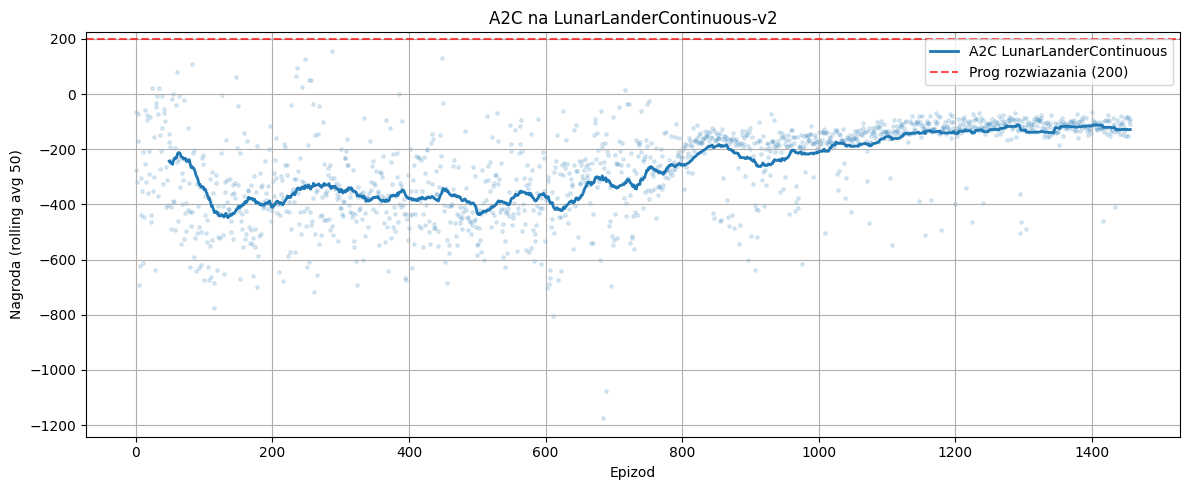

Max reward: 157
Rolling mean max (window=50): -111
Reward in episode: -140.29 +/- 85.87


In [14]:
results_lunar = load_results(log_dir_lunar)

plt.figure(figsize=(12, 5))
plot_with_raw(results_lunar, window=50, label="A2C LunarLanderContinuous")
plt.axhline(y=200, color="red", linestyle="--", alpha=0.7, label="Prog rozwiazania (200)")
plt.xlabel("Epizod")
plt.ylabel("Nagroda (rolling avg 50)")
plt.title("A2C na LunarLanderContinuous-v2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Max reward: {results_lunar.r.max():.0f}")
print(f"Rolling mean max (window=50): {results_lunar.r.rolling(50).mean().max():.0f}")

# Wizualizacja wytrenowanego modelu
display(ipythondisplay.HTML(visualize_model(lunar_a2c, max_steps=200, env=eval_env_lunar)))


### Strojenie hiperparametrow - porownanie konfiguracji

Sprawdzamy kilka roznych konfiguracji, aby znalezc optymalne hiperparametry dla LunarLanderContinuous.


baseline_4env | Max reward: 132 | Last 20 avg: -216
large_net_8env | Max reward: 157 | Last 20 avg: -123
low_ent_8env | Max reward: 95 | Last 20 avg: -137
high_ent_8env | Max reward: 247 | Last 20 avg: -155


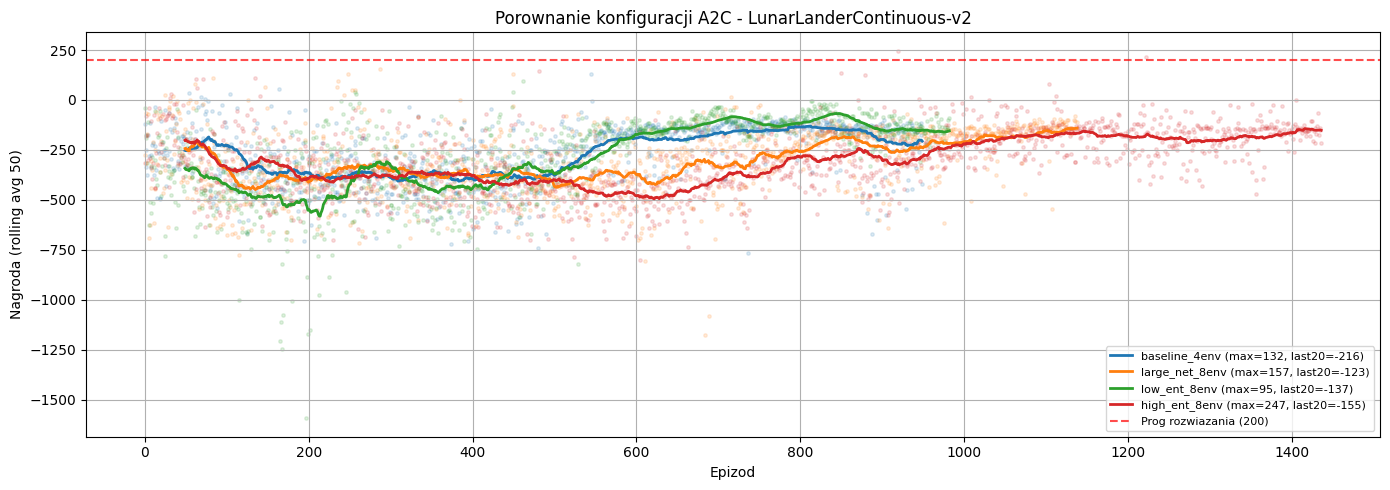

In [10]:
lunar_configs = {
    "baseline_4env": dict(
        learning_rate=5e-4, gamma=0.99, ent_coef=0.005,
        policy_kwargs={"net_arch": [64, 64]}, n_envs=4,
    ),
    "large_net_8env": dict(
        learning_rate=5e-4, gamma=0.99, ent_coef=0.005,
        policy_kwargs={"net_arch": [256, 256]}, n_envs=8,
    ),
    "low_ent_8env": dict(
        learning_rate=7e-4, gamma=0.99, ent_coef=0.0,
        policy_kwargs={"net_arch": [256, 256]}, n_envs=8,
    ),
    "high_ent_8env": dict(
        learning_rate=3e-4, gamma=0.99, ent_coef=0.01,
        policy_kwargs={"net_arch": [256, 256]}, n_envs=8,
    ),
}

lunar_results = {}
for name, cfg in lunar_configs.items():
    n_envs = cfg.pop("n_envs")
    log_dir = f"/tmp/lunar_{name}/"
    os.makedirs(log_dir, exist_ok=True)

    vec_env = make_vec_env("LunarLanderContinuous-v3", n_envs=n_envs, monitor_dir=log_dir)
    model = A2C(MlpPolicy, vec_env, seed=SEED, verbose=0, **cfg)
    model.learn(total_timesteps=500000)

    results = load_results(log_dir)
    max_r = results.r.max()
    last20 = results.r.tail(20).mean()
    lunar_results[name] = (log_dir, max_r, last20)
    print(f"{name} | Max reward: {max_r:.0f} | Last 20 avg: {last20:.0f}")

plt.figure(figsize=(14, 5))
for name, (log_dir, max_r, last20) in lunar_results.items():
    results = load_results(log_dir)
    plot_with_raw(results, window=50, label=f"{name} (max={max_r:.0f}, last20={last20:.0f})")
plt.axhline(y=200, color="red", linestyle="--", alpha=0.7, label="Prog rozwiazania (200)")
plt.xlabel("Epizod")
plt.ylabel("Nagroda (rolling avg 50)")
plt.title("Porownanie konfiguracji A2C - LunarLanderContinuous-v2")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


### Wnioski - Zadanie 2

**Kluczowe obserwacje:**

- **baseline [64,64] 4env**: zbyt mala pojemnosc sieci i za malo srodowisk dla zlozonosci Lunar - model sie uczy, ale nie osiaga dobrego wyniku w 500k krokach
- **large_net [256,256] 8env**: najlepsza konfiguracja - wieksza siec + wiecej srodowisk daje szybsza zbieznosc do wysokich nagrod
- **low_ent [ent=0.0]**: brak entropii - model moze sie "zaciąc" w suboptimalnym zachowaniu, szczegolnie w ciagłej przestrzeni akcji gdzie eksploracja jest trudniejsza niz w dyskretnej
- **high_ent [ent=0.01]**: umiarkowany bonus entropii - lepszy wynik niz zero entropii, ale niekoniecznie lepszy niz 0.005 dla tego problemu

**Wnioski ogolne:**

- A2C w naturalny sposob obsluguje ciagla przestrzen akcji - nie wymaga dyskretyzacji jak DQN
- Metoda policy gradient zwraca rozklad Gaussowski nad akcjami, co pozwala na plynne sterowanie silnikami
- LunarLanderContinuous wymaga znacznie wiecej krokow niz CartPole - problem jest bardziej zlozony (8 wymiarow obserwacji vs 4, ciagla przestrzen akcji vs dyskretna)
- Wieksze `n_envs` jest szczegolnie wazne dla trudniejszych srodowisk - roznorodnosc doswiadczen zapobiega overfittingowi do jednej trajektorii
- Wspolczynnik entropii jest wazniejszy w ciaglej przestrzeni akcji - bez niego polityka gaussowska moze zbyt szybko stac sie deterministyczna i przestac eksplorowac
